2025-07-02 20:52:29.158684: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-02 20:52:29.166287: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751457149.175065  101098 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751457149.177734  101098 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1751457149.184482  101098 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

--- 1. Training GPR (Gaussian Noise) ---
╒═════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════╕
│ name                    │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │      value │
╞═════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════╡
│ GPR.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 12.0994    │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────┤
│ GPR.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │  2.85612   │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────┤
│ GPR.likelihood.variance │ Parameter │ Softplus + Shift │         │ True        │ ()      │ float64 │  0.0810755 │
╘═════════════════════════╧════

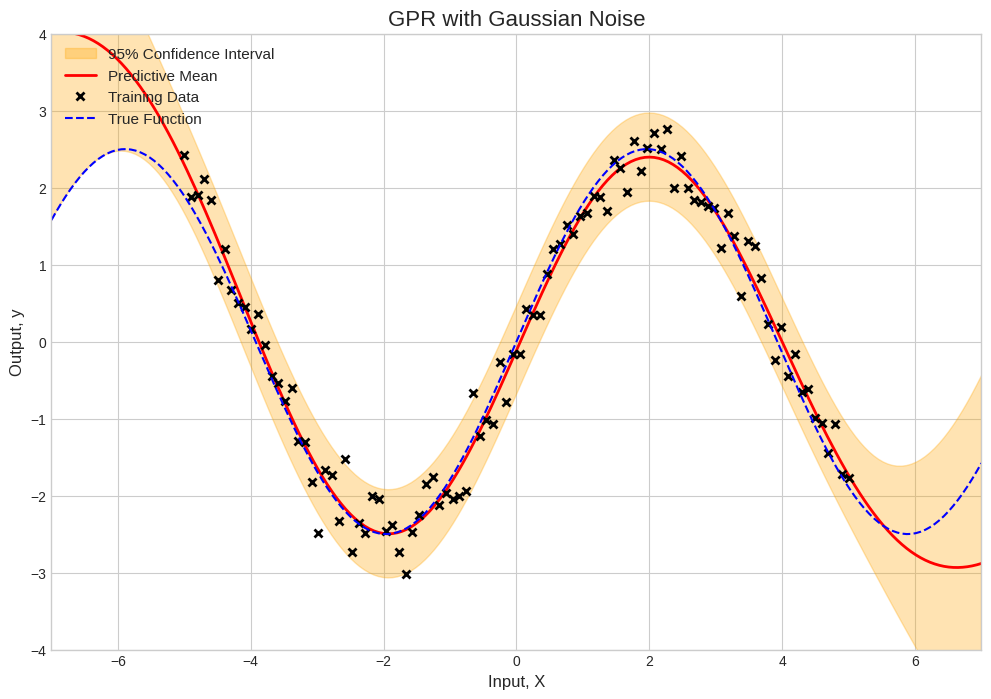


--- 2. Training VGP (Student-t Noise) ---
╒═════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═══════════════╤═════════╤══════════════════════════════════════════════════════╕
│ name                    │ class     │ transform        │ prior   │ trainable   │ shape         │ dtype   │ value                                                │
╞═════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═══════════════╪═════════╪══════════════════════════════════════════════════════╡
│ VGP.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()            │ float64 │ 11.13414                                             │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼───────────────┼─────────┼──────────────────────────────────────────────────────┤
│ VGP.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()            │ float64 │ 2.80639                     

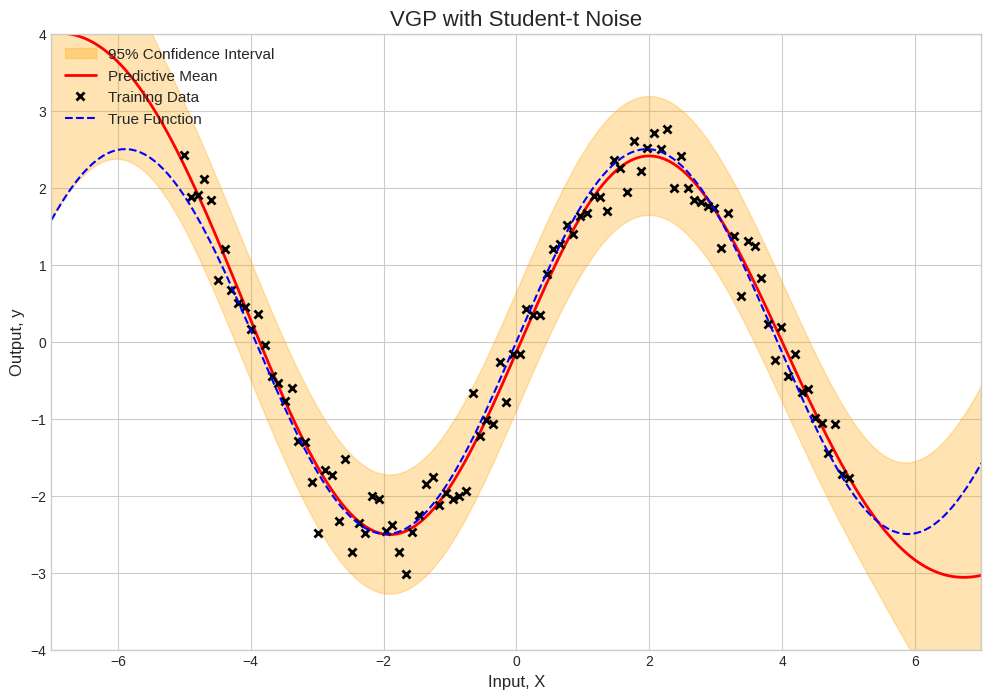


--- 3. Training SGPR (Gaussian Noise) ---
╒══════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════════════════╕
│ name                     │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value               │
╞══════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════════════════╡
│ SGPR.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 12.09953            │
├──────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────────────┤
│ SGPR.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 2.85613             │
├──────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────────────┤
│ SGPR.likelihood.variance │ Parameter │ Softplus + Shift │         │ True 

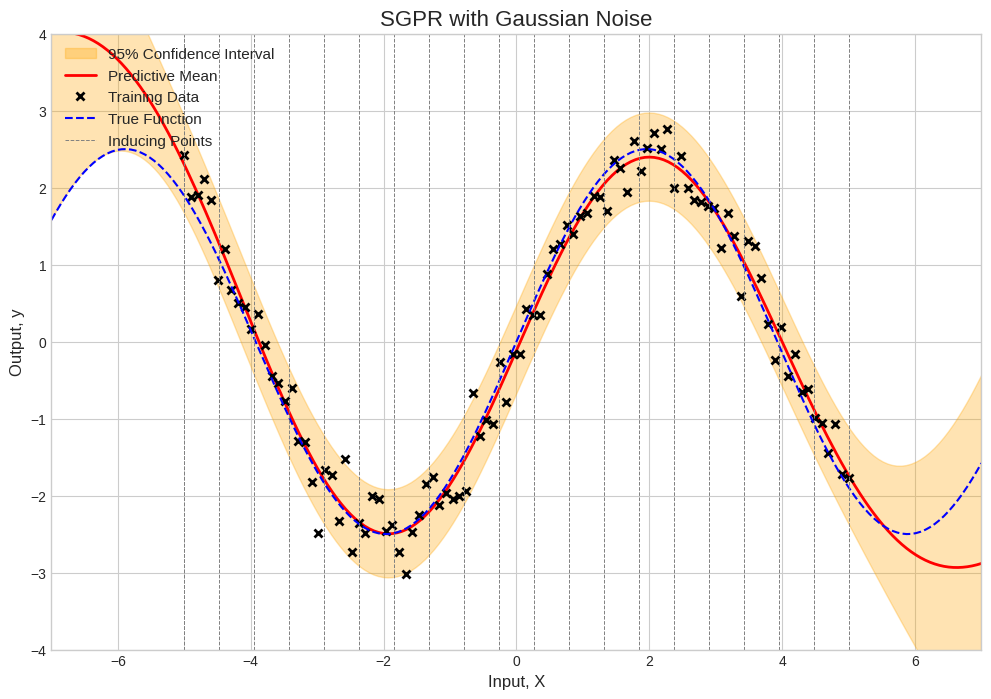


--- 4. Training SVGP (Student-t Noise) ---
╒══════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════════╤═════════╤══════════════════════════════════════════════════════╕
│ name                     │ class     │ transform        │ prior   │ trainable   │ shape       │ dtype   │ value                                                │
╞══════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════════╪═════════╪══════════════════════════════════════════════════════╡
│ SVGP.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()          │ float64 │ 11.61569                                             │
├──────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────────┼─────────┼──────────────────────────────────────────────────────┤
│ SVGP.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()          │ float64 │ 2.82394                          

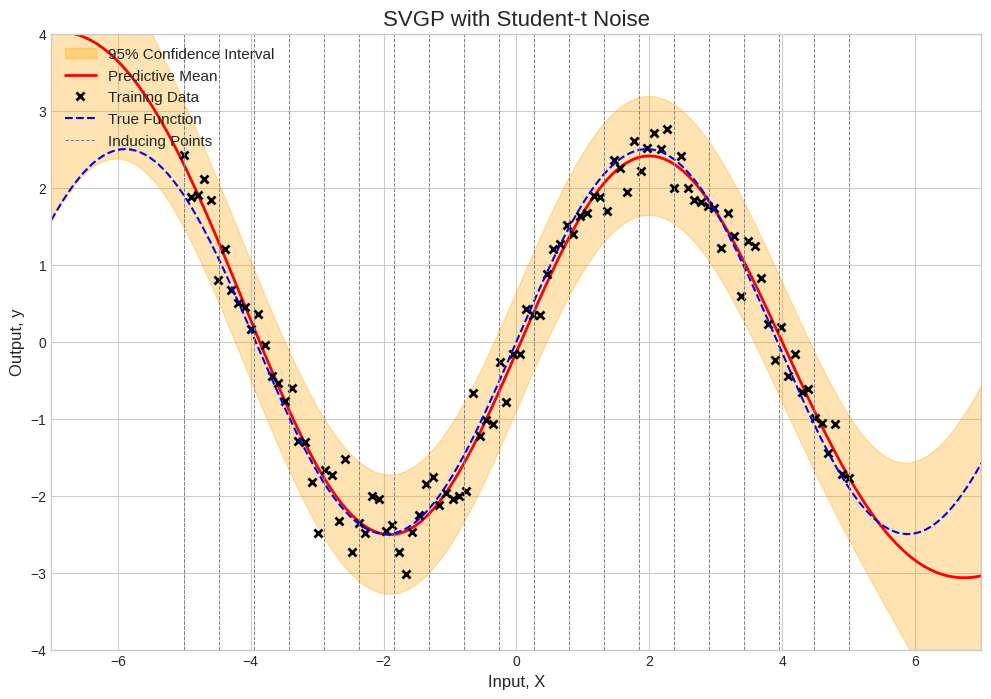

In [1]:
import numpy as np
import tensorflow as tf
import gpflow
import matplotlib.pyplot as plt

# 再現性のためのシード設定
np.random.seed(0)
tf.random.set_seed(0)

# Matplotlibのスタイル設定
plt.style.use('seaborn-v0_8-whitegrid')

# --------------------------------------------------------------------------
# 1. 合成データの生成 (元コードと同様)
# --------------------------------------------------------------------------
N = 100
X_train = np.linspace(-5, 5, N).reshape(-1, 1)
y_true = np.sin(X_train * 0.8) * 2.5
noise = np.random.randn(N, 1) * 0.3 # ガウスノイズ
y_train = y_true + noise

# GPflowで使いやすいようにタプルにまとめる
data = (tf.convert_to_tensor(X_train, dtype=tf.float64), 
        tf.convert_to_tensor(y_train, dtype=tf.float64))

# 予測用のテストデータ
X_test = np.linspace(-7, 7, 200).reshape(-1, 1)


# --------------------------------------------------------------------------
# 2. 結果をプロットするためのヘルパー関数
# --------------------------------------------------------------------------
def plot_result(model, title, inducing_points=None):
    """ガウス過程モデルの予測結果をプロットする関数"""
    mean, var = model.predict_y(X_test)
    std = tf.sqrt(var)

    plt.figure(figsize=(12, 8))
    
    # 95%信頼区間
    plt.fill_between(
        X_test.flatten(),
        (mean - 1.96 * std).numpy().flatten(),
        (mean + 1.96 * std).numpy().flatten(),
        color='orange',
        alpha=0.3,
        label='95% Confidence Interval'
    )
    # 予測平均、学習データ、真の関数
    plt.plot(X_test, mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data')
    plt.plot(X_test, np.sin(X_test * 0.8) * 2.5, 'b--', label='True Function')

    # 誘導点（もしあれば）をプロット
    if inducing_points is not None:
        # 誘導点の位置を縦の破線で示す
        for z_val in inducing_points.numpy().flatten():
            plt.axvline(x=z_val, color='gray', linestyle='--', linewidth=0.7)
        # 凡例用に1本だけラベル付きで描画
        plt.axvline(x=inducing_points.numpy().flatten()[0], color='gray', linestyle='--', linewidth=0.7, label='Inducing Points')

    plt.title(title, fontsize=16)
    plt.xlabel('Input, X', fontsize=12)
    plt.ylabel('Output, y', fontsize=12)
    plt.legend(loc='upper left', fontsize=11)
    plt.xlim(-7, 7)
    plt.ylim(-4, 4)
    plt.show()

# --------------------------------------------------------------------------
# 3. 各モデルのセットアップ、学習、可視化
# --------------------------------------------------------------------------

# --- モデル 1: GPR (i.i.d. Gaussian noise) ---
print("--- 1. Training GPR (Gaussian Noise) ---")
# RBFカーネル (Squared Exponential)
kernel_gpr = gpflow.kernels.SquaredExponential(lengthscales=1.0, variance=1.0)

# GPRモデルの定義
# ガウス尤度はモデルに組み込まれている
model_gpr = gpflow.models.GPR(data=data, kernel=kernel_gpr)

# ハイパーパラメータの最適化
optimizer = gpflow.optimizers.Scipy()
optimizer.minimize(model_gpr.training_loss, model_gpr.trainable_variables, options=dict(maxiter=1000))

# 最適化されたハイパーパラメータの表示
gpflow.utilities.print_summary(model_gpr)
plot_result(model_gpr, 'GPR with Gaussian Noise')


# --- モデル 2: VGP (Student-t noise) ---
print("\n--- 2. Training VGP (Student-t Noise) ---")
kernel_vgp = gpflow.kernels.SquaredExponential(lengthscales=1.0, variance=1.0)
# スチューデントのt分布尤度
likelihood_vgp = gpflow.likelihoods.StudentT(scale=0.1, df=3.0) # df: 自由度

# VGPモデルの定義 (変分推論を使用)
model_vgp = gpflow.models.VGP(data=data, kernel=kernel_vgp, likelihood=likelihood_vgp, num_latent_gps=1)

# 最適化
optimizer.minimize(model_vgp.training_loss, model_vgp.trainable_variables, options=dict(maxiter=1000))

gpflow.utilities.print_summary(model_vgp)
plot_result(model_vgp, 'VGP with Student-t Noise')


# --- モデル 3: SGPR (i.i.d. Gaussian noise) ---
print("\n--- 3. Training SGPR (Gaussian Noise) ---")
# 誘導点 (Inducing Points) の設定
M = 20  # 誘導点の数
inducing_points_sgpr = tf.constant(np.linspace(-5, 5, M).reshape(-1, 1), dtype=tf.float64)

kernel_sgpr = gpflow.kernels.SquaredExponential(lengthscales=1.0, variance=1.0)

# SGPRモデルの定義
model_sgpr = gpflow.models.SGPR(
    data=data, 
    kernel=kernel_sgpr, 
    inducing_variable=inducing_points_sgpr
)

# 最適化
optimizer.minimize(model_sgpr.training_loss, model_sgpr.trainable_variables, options=dict(maxiter=1000))

gpflow.utilities.print_summary(model_sgpr)
plot_result(model_sgpr, 'SGPR with Gaussian Noise', inducing_points=inducing_points_sgpr)


# --- モデル 4: SVGP (Student-t noise) ---
print("\n--- 4. Training SVGP (Student-t Noise) ---")
# 誘導点 (SGPRと同じものを使用)
inducing_points_svgp = tf.constant(np.linspace(-5, 5, M).reshape(-1, 1), dtype=tf.float64)

kernel_svgp = gpflow.kernels.SquaredExponential(lengthscales=1.0, variance=1.0)
likelihood_svgp = gpflow.likelihoods.StudentT(scale=0.1, df=3.0)

# SVGPモデルの定義
model_svgp = gpflow.models.SVGP(
    kernel=kernel_svgp, 
    likelihood=likelihood_svgp, 
    inducing_variable=inducing_points_svgp,
    num_latent_gps=1
)

# SVGPの損失関数はデータを引数に取るため、クロージャでラップする
@tf.function
def training_loss_closure():
    return model_svgp.training_loss(data)

# 最適化
optimizer.minimize(training_loss_closure, model_svgp.trainable_variables, options=dict(maxiter=1000))

gpflow.utilities.print_summary(model_svgp)
plot_result(model_svgp, 'SVGP with Student-t Noise', inducing_points=inducing_points_svgp)

--- 1. Training GPR (Gaussian Noise) ---
╒═════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤══════════╕
│ name                    │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │    value │
╞═════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪══════════╡
│ GPR.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 2.05658  │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼──────────┤
│ GPR.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.581347 │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼──────────┤
│ GPR.likelihood.variance │ Parameter │ Softplus + Shift │         │ True        │ ()      │ float64 │ 8.16539  │
╘═════════════════════════╧═══════════╧════════

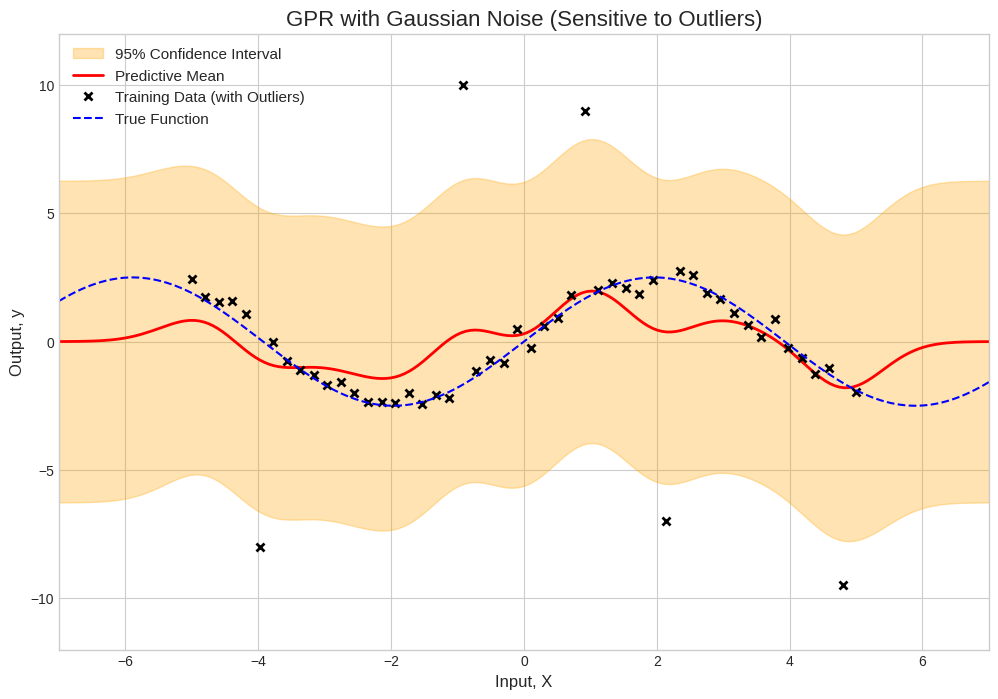


--- 2. Training VGP (Student-t Noise) ---
╒═════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════════╤═════════╤══════════════════════════════════════════════════════╕
│ name                    │ class     │ transform        │ prior   │ trainable   │ shape       │ dtype   │ value                                                │
╞═════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════════╪═════════╪══════════════════════════════════════════════════════╡
│ VGP.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()          │ float64 │ 9.19185                                              │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────────┼─────────┼──────────────────────────────────────────────────────┤
│ VGP.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()          │ float64 │ 2.55058                                 

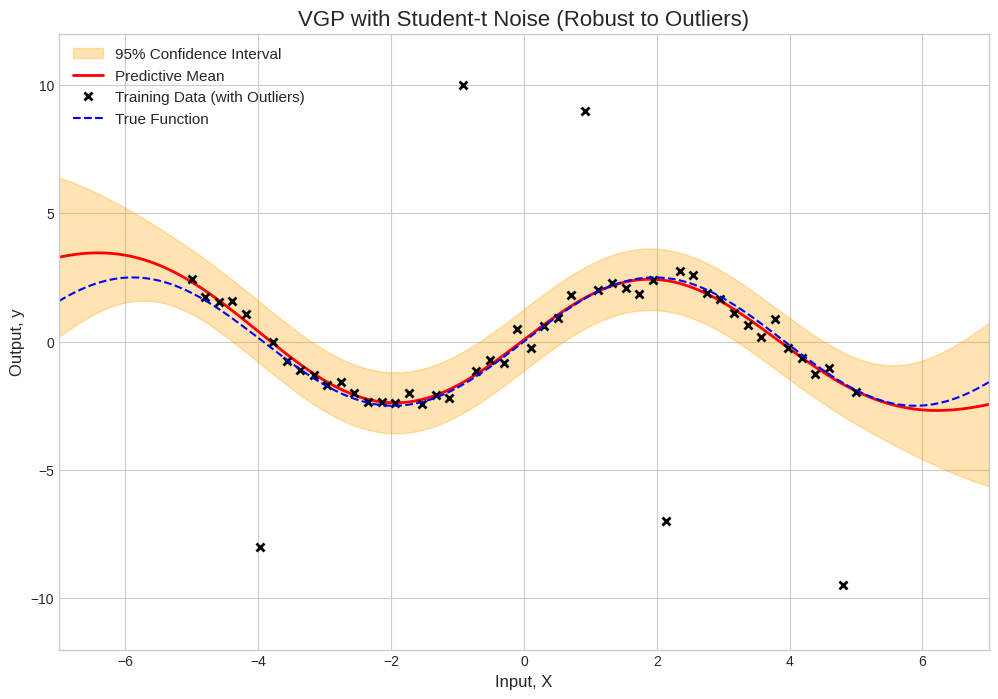


--- 3. Training SGPR (Gaussian Noise) ---
╒══════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═══════════════╕
│ name                     │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value         │
╞══════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═══════════════╡
│ SGPR.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.81474       │
├──────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼───────────────┤
│ SGPR.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.35971       │
├──────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼───────────────┤
│ SGPR.likelihood.variance │ Parameter │ Softplus + Shift │         │ True        │ ()      │ float64 │ 8.632        

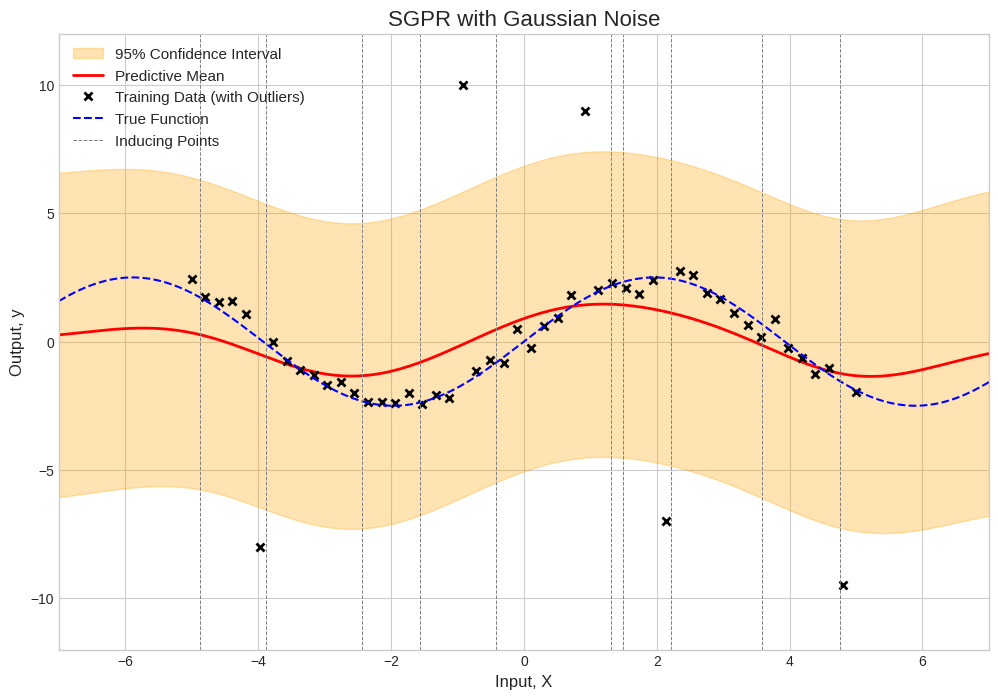


--- 4. Training SVGP (Student-t Noise) ---
╒══════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════════╤═════════╤══════════════════════════╕
│ name                     │ class     │ transform        │ prior   │ trainable   │ shape       │ dtype   │ value                    │
╞══════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════════╪═════════╪══════════════════════════╡
│ SVGP.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()          │ float64 │ 9.25102                  │
├──────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────────┼─────────┼──────────────────────────┤
│ SVGP.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()          │ float64 │ 2.55389                  │
├──────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────────┼─────────┼──────────────────────────┤
│ SVGP.like

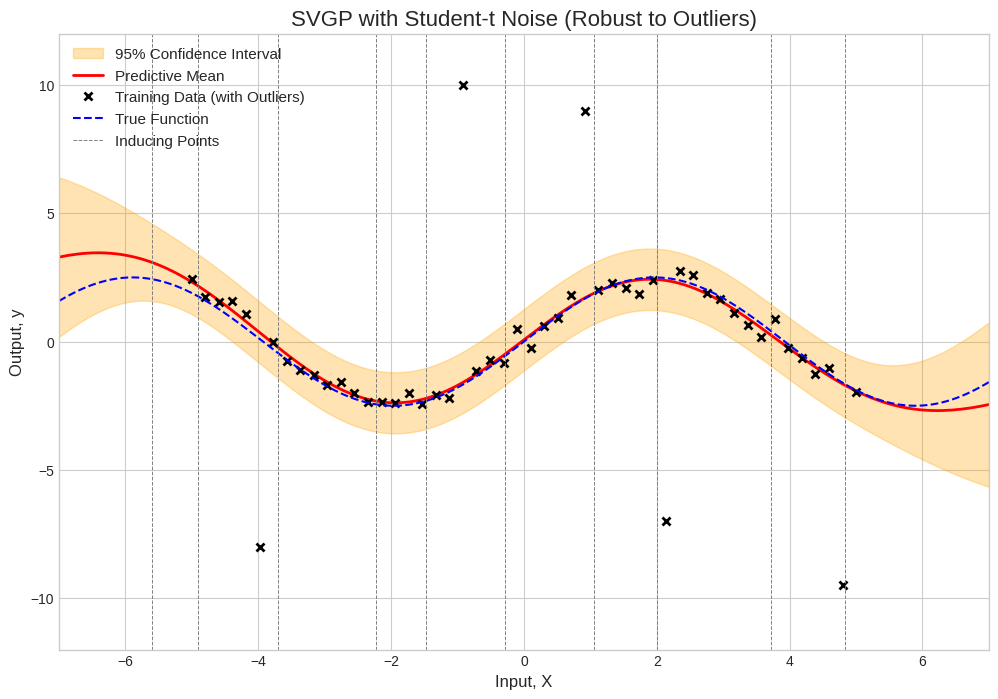

In [12]:
import numpy as np
import tensorflow as tf
import gpflow
import matplotlib.pyplot as plt

# 再現性のためのシード設定
np.random.seed(0)
tf.random.set_seed(0)

# Matplotlibのスタイル設定
plt.style.use('seaborn-v0_8-whitegrid')

# --------------------------------------------------------------------------
# 1. 合成データの生成 (外れ値を追加)
# --------------------------------------------------------------------------
N = 50
X_train = np.linspace(-5, 5, N).reshape(-1, 1)
y_true = np.sin(X_train * 0.8) * 2.5
noise = np.random.randn(N, 1) * 0.3 # ガウスノイズ
y_train = y_true + noise

# --- ここで意図的に外れ値を追加 ---
outlier_indices = [5, 20, 29, 35, 48]
y_train[outlier_indices] = np.array([-8.0, 10.0, 9.0, -7.0, -9.5]).reshape(-1, 1)
# --------------------------------

# GPflowで使いやすいようにタプルにまとめる
data = (tf.convert_to_tensor(X_train, dtype=tf.float64), 
        tf.convert_to_tensor(y_train, dtype=tf.float64))

# 予測用のテストデータ
X_test = np.linspace(-7, 7, 200).reshape(-1, 1)


# --------------------------------------------------------------------------
# 2. 結果をプロットするためのヘルパー関数
# --------------------------------------------------------------------------
def plot_result(model, title, inducing_points=None):
    """ガウス過程モデルの予測結果をプロットする関数"""
    mean, var = model.predict_y(X_test)
    std = tf.sqrt(var)

    plt.figure(figsize=(12, 8))
    
    # 95%信頼区間
    plt.fill_between(
        X_test.flatten(),
        (mean - 1.96 * std).numpy().flatten(),
        (mean + 1.96 * std).numpy().flatten(),
        color='orange',
        alpha=0.3,
        label='95% Confidence Interval'
    )
    # 予測平均、学習データ、真の関数
    plt.plot(X_test, mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with Outliers)')
    plt.plot(X_test, np.sin(X_test * 0.8) * 2.5, 'b--', label='True Function')

    # 誘導点（もしあれば）をプロット
    if inducing_points is not None:
        # --- ここを修正 ---
        # InducingPointsオブジェクトから.Zで実際の変数を取得する
        iv_locs = inducing_points.Z.numpy().flatten()
        # -----------------
        
        # 凡例用に1本だけラベル付きで描画
        plt.axvline(x=iv_locs[0], color='gray', linestyle='--', linewidth=0.7, label='Inducing Points')
        # 残りの誘導点の位置を縦の破線で示す
        for z_val in iv_locs[1:]:
            plt.axvline(x=z_val, color='gray', linestyle='--', linewidth=0.7)
        

    plt.title(title, fontsize=16)
    plt.xlabel('Input, X', fontsize=12)
    plt.ylabel('Output, y', fontsize=12)
    plt.legend(loc='upper left', fontsize=11)
    plt.xlim(-7, 7)
    # 外れ値が見えるようにy軸の範囲を調整
    plt.ylim(-12, 12)
    plt.show()

# --------------------------------------------------------------------------
# 3. 各モデルのセットアップ、学習、可視化
# --------------------------------------------------------------------------

# --- モデル 1: GPR (ガウスノイズ) ---
# 外れ値に弱いモデルの代表
print("--- 1. Training GPR (Gaussian Noise) ---")
kernel_gpr = gpflow.kernels.SquaredExponential(lengthscales=1.0, variance=1.0)
model_gpr = gpflow.models.GPR(data=data, kernel=kernel_gpr)
optimizer = gpflow.optimizers.Scipy()
optimizer.minimize(model_gpr.training_loss, model_gpr.trainable_variables, options=dict(maxiter=1000))
gpflow.utilities.print_summary(model_gpr)
plot_result(model_gpr, 'GPR with Gaussian Noise (Sensitive to Outliers)')


# --- モデル 2: VGP (スチューデントのt分布ノイズ) ---
# 非スパースで外れ値に強いモデル
print("\n--- 2. Training VGP (Student-t Noise) ---")
kernel_vgp = gpflow.kernels.SquaredExponential(lengthscales=1.0, variance=1.0)
likelihood_vgp = gpflow.likelihoods.StudentT(scale=1.0, df=3.0) # df: 自由度
model_vgp = gpflow.models.VGP(data=data, kernel=kernel_vgp, likelihood=likelihood_vgp, num_latent_gps=1)
optimizer.minimize(model_vgp.training_loss, model_vgp.trainable_variables, options=dict(maxiter=1000))
gpflow.utilities.print_summary(model_vgp)
plot_result(model_vgp, 'VGP with Student-t Noise (Robust to Outliers)')


# --- モデル 3: SGPR (ガウスノイズ) ---
# スパースで外れ値に弱いモデル
print("\n--- 3. Training SGPR (Gaussian Noise) ---")
M = 10  # 誘導点の数
inducing_points = np.linspace(-5, 5, M).reshape(-1, 1)
inducing_variable_sgpr = gpflow.inducing_variables.InducingPoints(inducing_points)
kernel_sgpr = gpflow.kernels.SquaredExponential(lengthscales=1.0, variance=1.0)
model_sgpr = gpflow.models.SGPR(data=data, kernel=kernel_sgpr, inducing_variable=inducing_variable_sgpr)
optimizer.minimize(model_sgpr.training_loss, model_sgpr.trainable_variables, options=dict(maxiter=1000))
gpflow.utilities.print_summary(model_sgpr)
plot_result(model_sgpr, 'SGPR with Gaussian Noise', inducing_points=model_sgpr.inducing_variable)


# --- モデル 4: SVGP (スチューデントのt分布ノイズ) ---
# スパースで外れ値に強いモデル
print("\n--- 4. Training SVGP (Student-t Noise) ---")
inducing_variable_svgp = gpflow.inducing_variables.InducingPoints(inducing_points)
kernel_svgp = gpflow.kernels.SquaredExponential(lengthscales=1.0, variance=1.0)
likelihood_svgp = gpflow.likelihoods.StudentT(scale=1.0, df=3.0)
model_svgp = gpflow.models.SVGP(
    kernel=kernel_svgp, 
    likelihood=likelihood_svgp, 
    inducing_variable=inducing_variable_svgp,
    num_latent_gps=1
)
@tf.function
def training_loss_closure():
    return model_svgp.training_loss(data)
optimizer.minimize(training_loss_closure, model_svgp.trainable_variables, options=dict(maxiter=1000))
gpflow.utilities.print_summary(model_svgp)
plot_result(model_svgp, 'SVGP with Student-t Noise (Robust to Outliers)', inducing_points=model_svgp.inducing_variable)


In [7]:
model_svgp.kernel.lengthscales.prior

In [8]:
gpflow.utilities.print_summary(model_gpr)

╒═════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                    │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │   value │
╞═════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ GPR.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 6.19222 │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ GPR.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 2.03865 │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ GPR.likelihood.variance │ Parameter │ Softplus + Shift │         │ True        │ ()      │ float64 │ 2.30782 │
╘═════════════════════════╧═══════════╧══════════════════╧═════════╧═════════════╧═════════╧════

--- 1. Training GPR (Gaussian Noise) ---
╒═════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                    │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │   value │
╞═════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ GPR.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.72257 │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ GPR.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.44439 │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ GPR.likelihood.variance │ Parameter │ Softplus + Shift │         │ True        │ ()      │ float64 │ 2.9059  │
╘═════════════════════════╧═══════════╧════════════════

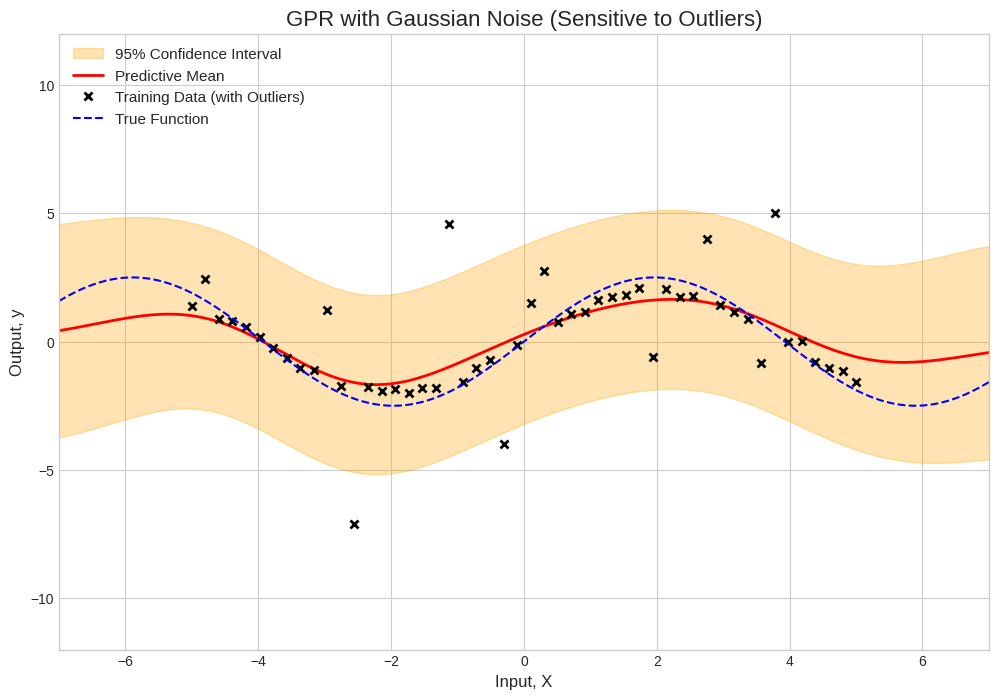


--- 2. Training VGP (Student-t Noise) ---
╒═════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════════╤═════════╤══════════════════════════════════════════════════════╕
│ name                    │ class     │ transform        │ prior   │ trainable   │ shape       │ dtype   │ value                                                │
╞═════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════════╪═════════╪══════════════════════════════════════════════════════╡
│ VGP.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()          │ float64 │ 5.71018                                              │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────────┼─────────┼──────────────────────────────────────────────────────┤
│ VGP.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()          │ float64 │ 2.53763                                 

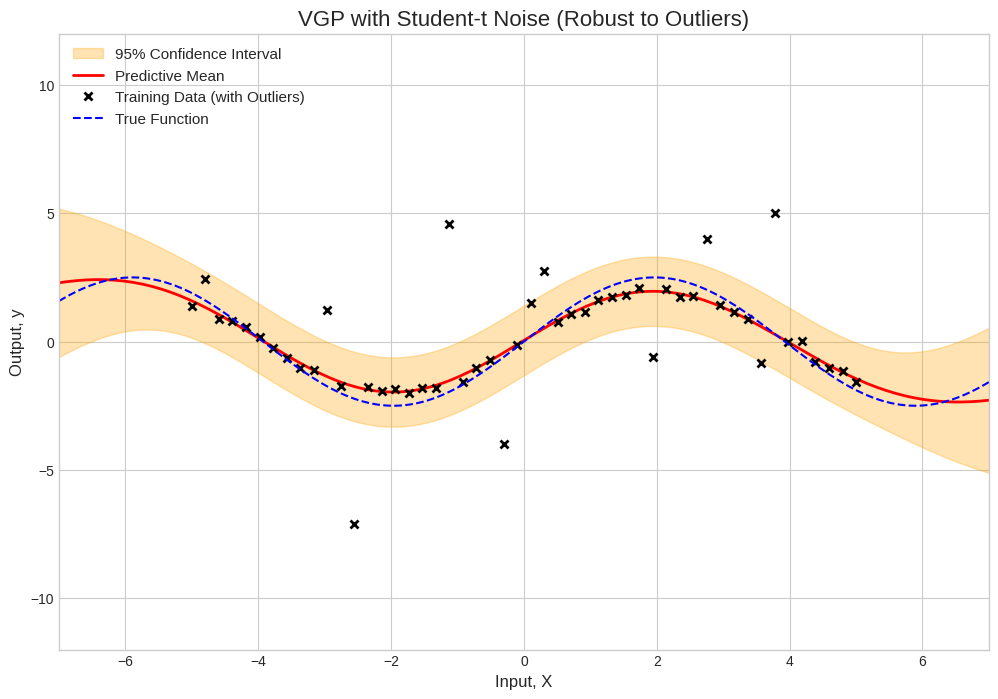


--- 3. Training SGPR (Gaussian Noise) ---
╒══════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═══════════════╕
│ name                     │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value         │
╞══════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═══════════════╡
│ SGPR.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.72257       │
├──────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼───────────────┤
│ SGPR.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.44439       │
├──────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼───────────────┤
│ SGPR.likelihood.variance │ Parameter │ Softplus + Shift │         │ True        │ ()      │ float64 │ 2.90591      

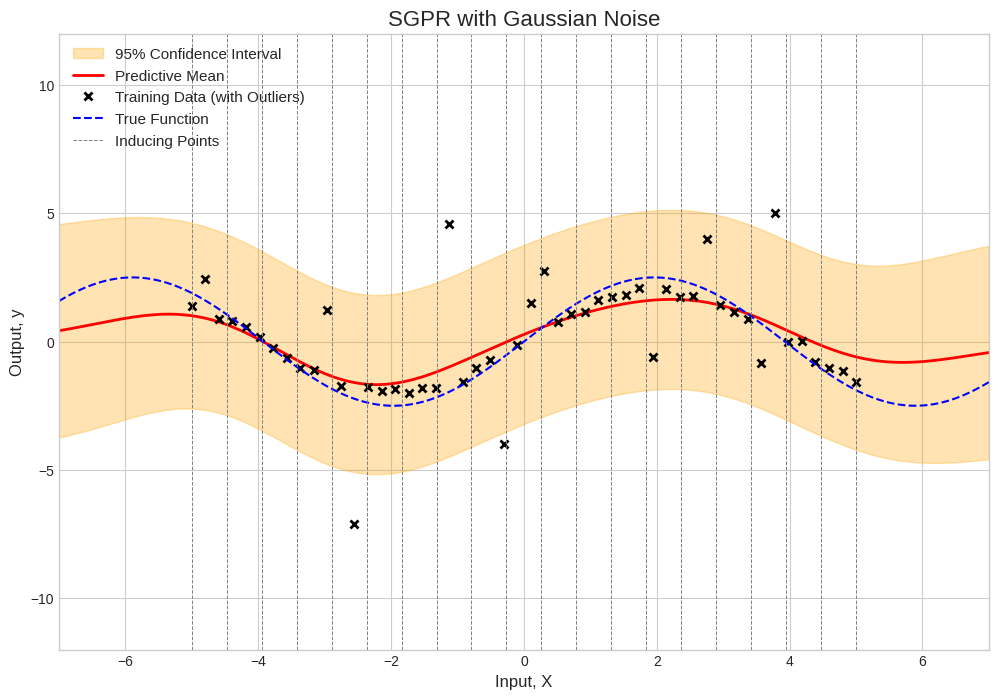


--- 4. Training SVGP (Student-t Noise) ---
╒══════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════════╤═════════╤══════════════════════════════════════════════════════╕
│ name                     │ class     │ transform        │ prior   │ trainable   │ shape       │ dtype   │ value                                                │
╞══════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════════╪═════════╪══════════════════════════════════════════════════════╡
│ SVGP.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()          │ float64 │ 5.69583                                              │
├──────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────────┼─────────┼──────────────────────────────────────────────────────┤
│ SVGP.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()          │ float64 │ 2.53685                          

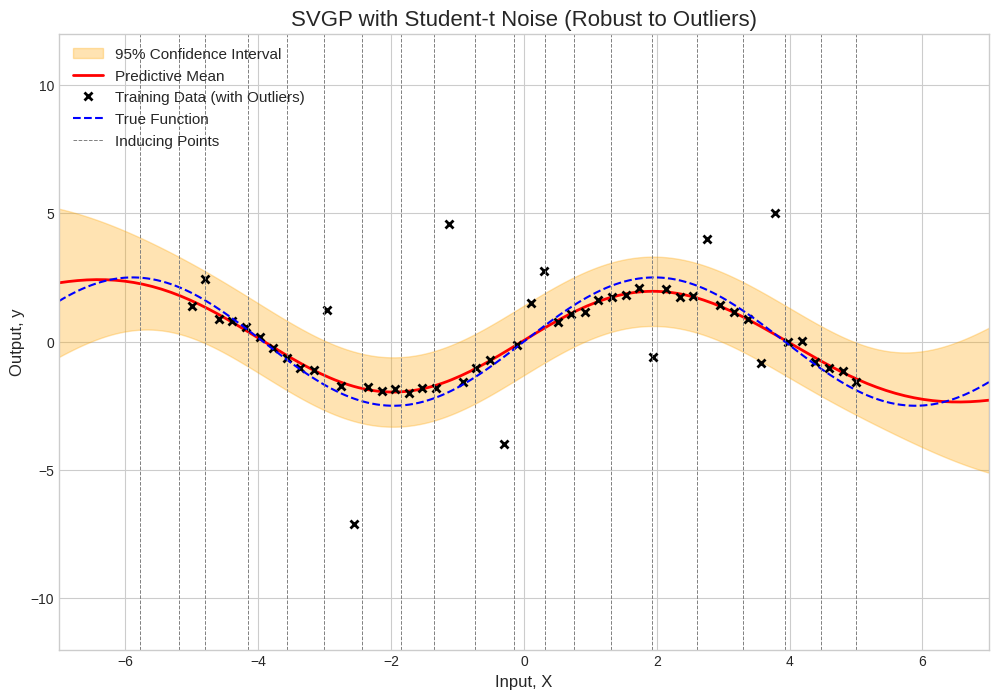

In [20]:
import numpy as np
import tensorflow as tf
import gpflow
import matplotlib.pyplot as plt
from scipy.stats import t

# # 再現性のためのシード設定
# np.random.seed(0)
# tf.random.set_seed(0)

# Matplotlibのスタイル設定
plt.style.use('seaborn-v0_8-whitegrid')

# --------------------------------------------------------------------------
# 1. 合成データの生成 (ユーザー指定のロジック)
# --------------------------------------------------------------------------
N = 50
X_train = np.linspace(-5, 5, N).reshape(-1, 1)
y_true = np.sin(X_train * 0.8) * 2.0
noise = np.random.randn(N, 1) * 0.1
y_train = y_true + noise

# --- ユーザー指定のロジックで外れ値を追加 ---
# Student-t分布からのノイズを生成
outlier_noise = t.rvs(df=2, size=(N, 1)) * 0.5

# 10個のランダムな点にt分布ノイズを追加
outlier_indices = np.random.permutation(N)[:10]
y_train[outlier_indices] += outlier_noise[outlier_indices] * 3

# 2つの固定された外れ値を追加
y_train[23] = -4.0
y_train[43] = 5.0
# --------------------------------

# GPflowで使いやすいようにタプルにまとめる
data = (tf.convert_to_tensor(X_train, dtype=tf.float64), 
        tf.convert_to_tensor(y_train, dtype=tf.float64))

# 予測用のテストデータ
X_test = np.linspace(-7, 7, 200).reshape(-1, 1)


# --------------------------------------------------------------------------
# 2. 結果をプロットするためのヘルパー関数
# --------------------------------------------------------------------------
def plot_result(model, title, inducing_points=None):
    """ガウス過程モデルの予測結果をプロットする関数"""
    mean, var = model.predict_y(X_test)
    std = tf.sqrt(var)

    plt.figure(figsize=(12, 8))
    
    # 95%信頼区間
    plt.fill_between(
        X_test.flatten(),
        (mean - 1.96 * std).numpy().flatten(),
        (mean + 1.96 * std).numpy().flatten(),
        color='orange',
        alpha=0.3,
        label='95% Confidence Interval'
    )
    # 予測平均、学習データ、真の関数
    plt.plot(X_test, mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with Outliers)')
    plt.plot(X_test, np.sin(X_test * 0.8) * 2.5, 'b--', label='True Function')

    # 誘導点（もしあれば）をプロット
    if inducing_points is not None:
        # InducingPointsオブジェクトから.Zで実際の変数を取得する
        iv_locs = inducing_points.Z.numpy().flatten()
        
        # 凡例用に1本だけラベル付きで描画
        plt.axvline(x=iv_locs[0], color='gray', linestyle='--', linewidth=0.7, label='Inducing Points')
        # 残りの誘導点の位置を縦の破線で示す
        for z_val in iv_locs[1:]:
            plt.axvline(x=z_val, color='gray', linestyle='--', linewidth=0.7)
        

    plt.title(title, fontsize=16)
    plt.xlabel('Input, X', fontsize=12)
    plt.ylabel('Output, y', fontsize=12)
    plt.legend(loc='upper left', fontsize=11)
    plt.xlim(-7, 7)
    # 外れ値が見えるようにy軸の範囲を調整
    plt.ylim(-12, 12)
    plt.show()

# --------------------------------------------------------------------------
# 3. 各モデルのセットアップ、学習、可視化
# --------------------------------------------------------------------------

# --- モデル 1: GPR (ガウスノイズ) ---
print("--- 1. Training GPR (Gaussian Noise) ---")
kernel_gpr = gpflow.kernels.SquaredExponential(lengthscales=1.0, variance=1.0)
model_gpr = gpflow.models.GPR(data=data, kernel=kernel_gpr)
optimizer = gpflow.optimizers.Scipy()
optimizer.minimize(model_gpr.training_loss, model_gpr.trainable_variables, options=dict(maxiter=1000))
gpflow.utilities.print_summary(model_gpr)
plot_result(model_gpr, 'GPR with Gaussian Noise (Sensitive to Outliers)')


# --- モデル 2: VGP (スチューデントのt分布ノイズ) ---
print("\n--- 2. Training VGP (Student-t Noise) ---")
kernel_vgp = gpflow.kernels.SquaredExponential(lengthscales=1.0, variance=1.0)
likelihood_vgp = gpflow.likelihoods.StudentT(scale=1.0, df=3.0) # df: 自由度
model_vgp = gpflow.models.VGP(data=data, kernel=kernel_vgp, likelihood=likelihood_vgp, num_latent_gps=1)
optimizer.minimize(model_vgp.training_loss, model_vgp.trainable_variables, options=dict(maxiter=1000))
gpflow.utilities.print_summary(model_vgp)
plot_result(model_vgp, 'VGP with Student-t Noise (Robust to Outliers)')


# --- モデル 3: SGPR (ガウスノイズ) ---
print("\n--- 3. Training SGPR (Gaussian Noise) ---")
M = 20  # 誘導点の数
inducing_points = np.linspace(-5, 5, M).reshape(-1, 1)
inducing_variable_sgpr = gpflow.inducing_variables.InducingPoints(inducing_points)
kernel_sgpr = gpflow.kernels.SquaredExponential(lengthscales=1.0, variance=1.0)
model_sgpr = gpflow.models.SGPR(data=data, kernel=kernel_sgpr, inducing_variable=inducing_variable_sgpr)
optimizer.minimize(model_sgpr.training_loss, model_sgpr.trainable_variables, options=dict(maxiter=1000))
gpflow.utilities.print_summary(model_sgpr)
plot_result(model_sgpr, 'SGPR with Gaussian Noise', inducing_points=model_sgpr.inducing_variable)


# --- モデル 4: SVGP (スチューデントのt分布ノイズ) ---
print("\n--- 4. Training SVGP (Student-t Noise) ---")
inducing_variable_svgp = gpflow.inducing_variables.InducingPoints(inducing_points)
kernel_svgp = gpflow.kernels.SquaredExponential(lengthscales=1.0, variance=1.0)
likelihood_svgp = gpflow.likelihoods.StudentT(scale=1.0, df=3.0)
model_svgp = gpflow.models.SVGP(
    kernel=kernel_svgp, 
    likelihood=likelihood_svgp, 
    inducing_variable=inducing_variable_svgp,
    num_latent_gps=1
)
@tf.function
def training_loss_closure():
    return model_svgp.training_loss(data)
optimizer.minimize(training_loss_closure, model_svgp.trainable_variables, options=dict(maxiter=1000))
gpflow.utilities.print_summary(model_svgp)
plot_result(model_svgp, 'SVGP with Student-t Noise (Robust to Outliers)', inducing_points=model_svgp.inducing_variable)
